# **Project Name**    -Uber Supply Demand Gap Analysis



##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Manas Mahesh Kadu

# **Project Summary -**

Uber Supply Demand Gap Analysis

Uber is one of the world's leading ride-hailing platforms, connecting passengers with drivers through a mobile application. To provide a good customer experience, Uber must ensure that the supply of drivers matches customer demand. However, during peak hours or at certain locations, the number of ride requests may exceed the number of available drivers, creating a supply-demand gap. This gap can result in ride cancellations, long waiting times, and customers receiving a "No Cars Available" message. Understanding these patterns is essential for improving operational efficiency and customer satisfaction.

The objective of this project is to analyze the Uber Supply Demand Gap dataset using data analytics techniques to identify the major reasons behind unmet ride requests. The dataset contains information such as Request ID, Pickup Point, Driver ID, Request Timestamp, Drop Timestamp, and Ride Status. Using these attributes, the project investigates customer demand, ride completion rates, cancellations, and driver availability across different locations and time periods.

The project begins with data cleaning and preprocessing using Python and the Pandas library. Missing values were handled appropriately, timestamps were converted into datetime format, and additional features such as the request hour were extracted to support time-based analysis. Proper data preparation ensures accurate analysis and reliable business insights.

Exploratory Data Analysis (EDA) was performed using Python libraries including Pandas, Matplotlib, and Seaborn. Various visualizations were created to understand ride request distribution, ride status, pickup point trends, hourly demand, ride status by hour, and ride status by pickup location. Correlation heatmaps and pair plots were also used to examine relationships between numerical variables.

To complement the Python analysis, SQL queries were executed using SQLite to extract business insights from the dataset. SQL was used to calculate total ride requests, analyze ride status, compare pickup points, identify peak demand hours, and examine ride completion and cancellation patterns.

An interactive Excel dashboard was also created using Pivot Tables and Pivot Charts. The dashboard provides a clear visual summary of key performance indicators, allowing users to quickly understand ride demand, supply shortages, and service performance across different locations and time periods.

The analysis revealed that ride demand is highest during morning and evening peak hours. The Airport experiences a significant number of "No Cars Available" cases, indicating a shortage of drivers, while the City records a relatively higher number of ride cancellations. These findings suggest that better driver allocation, improved scheduling during peak hours, and demand forecasting can reduce the supply-demand gap and improve customer satisfaction.

Overall, this project demonstrates how Python, SQL, and Excel can be combined to perform end-to-end data analysis, generate meaningful business insights, and support data-driven decision-making.

# **GitHub Link -**

https://github.com/manas2067/Uber-Supply-Demand-Gap-Analysis/tree/main

# **Problem Statement**


Uber frequently faces a mismatch between customer demand and driver availability during certain hours and locations. This supply-demand gap results in ride cancellations, "No Cars Available" situations, and decreased customer satisfaction. The objective of this project is to analyze the Uber ride request data to identify the factors contributing to these issues and recommend data-driven solutions to improve service efficiency.

#### **Define Your Business Objective?**

The primary business objective is to identify the major causes of the Uber supply-demand gap by analyzing ride request patterns, pickup locations, ride statuses, and peak demand hours. The analysis aims to help Uber optimize driver allocation, reduce cancellations, minimize "No Cars Available" cases, improve ride completion rates, and enhance the overall customer experience through data-driven decision-making.

## ***1. Data Information***

### Import Libraries

In [52]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [53]:
df = pd.read_csv("Uber Request Data.csv")

In [54]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


### Dataset First View

In [55]:
# Dataset First Look
df

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47
...,...,...,...,...,...,...
6740,6745,City,NaN,No Cars Available,15-07-2016 23:49:03,NaN
6741,6752,Airport,NaN,No Cars Available,15-07-2016 23:50:05,NaN
6742,6751,City,NaN,No Cars Available,15-07-2016 23:52:06,NaN
6743,6754,City,NaN,No Cars Available,15-07-2016 23:54:39,NaN


### Dataset Rows & Columns count

In [56]:
# Dataset Rows & Columns count
df.shape

(6745, 6)

In [57]:
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='str')

### Dataset Information

In [58]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB


#### Duplicate Values

In [59]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [60]:
# Missing Values/Null Values Count
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

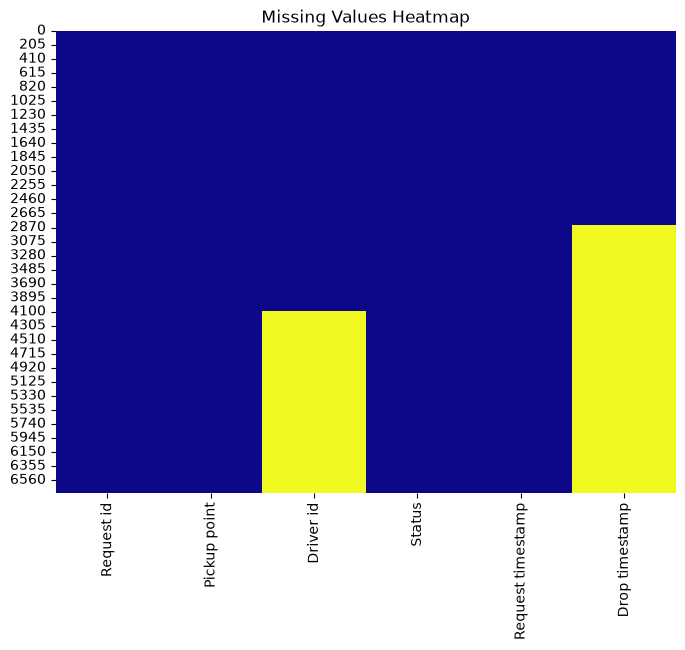

In [61]:
# Visualizing the missing values

plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap="plasma")
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains 6,745 rows and 6 columns. It includes three data types: int64, float64, and object. Missing values are present in the Driver id and Drop timestamp columns, with the Drop timestamp column having the highest number of missing values. The missing values in the Drop timestamp column are expected because the ride was either cancelled or no cars were available, so the trip was not completed. The dataset does not contain any duplicate rows.

## ***2. Understanding  Variables***

In [62]:
# Dataset Columns
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='str')

In [63]:
# Dataset Describe
df.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


### Variables Description

Request id: Unique ID assigned to each ride request.
Pickup point: Location where the ride was requested (Airport or City).
Driver id: Unique ID assigned to the driver. Missing values indicate no driver was assigned.
Status: Shows the ride status (Trip Completed, Cancelled, or No Cars Available).
Request timestamp: Date and time when the ride was requested.
Drop timestamp: Date and time when the ride ended. Missing values indicate the trip was not completed.

### Check Unique Values for each variable.

In [64]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f" unique values in {col}:")
    print(df[col].unique())
    print("-" * 50)

 unique values in Request id:
[ 619  867 1807 ... 6751 6754 6753]
--------------------------------------------------
 unique values in Pickup point:
<StringArray>
['Airport', 'City']
Length: 2, dtype: str
--------------------------------------------------
 unique values in Driver id:
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [65]:
# Write your code to make your dataset analysis ready.
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], format='mixed')
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], format='mixed')

### What all manipulations have you done and insights you found?

Checked the dataset for missing values, duplicate rows, data type and unique values.Converted the Request timestamp and Drop timestamp column into datetime formate for easier time based analysis.Found no duplicate rows.Missing values were persent in Driver ID and Drop timestamp mainly due to cancelled ride or no car available. 

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

C:\Users\Manas Kadu\AppData\Local\Temp\ipykernel_24228\3851890739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, palette='plasma')


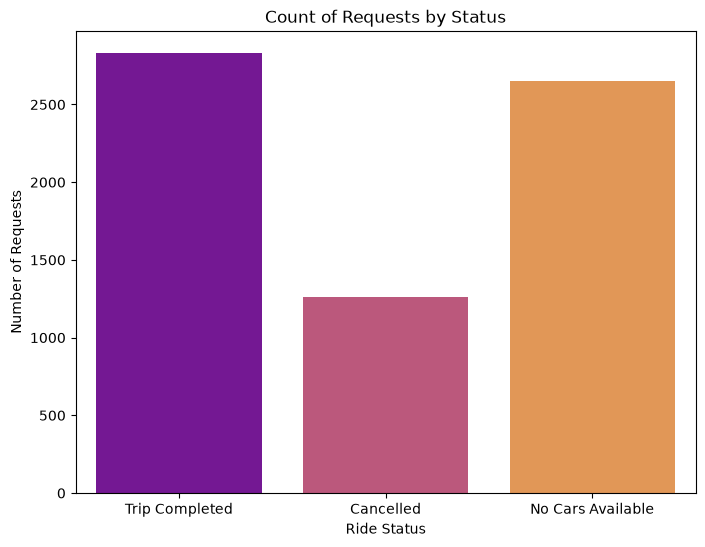

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(8,6))
sns.countplot(x='Status', data=df, hue_norm='plasma')
plt.title('Count of Requests by Status')
plt.xlabel('Ride Status')
plt.ylabel('Number of Requests')
plt.show()

##### 1. Why did you pick the specific chart?

I selected a count plot because the Status column is a categorical variable. A count plot helps compare the frequency of each ride status and makes it easy to understand the distribution of completed, cancelled, and no car available requests.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Trip Completed has the highest number of requests. However, a large number of requests could not be fulfilled because of "No Cars Available", while some rides were also cancelled. This indicates a supply-demand gap in the Uber service

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights will help create a positive business impact by helping Uber identify service issues and improve driver availability during peak hours. However, the high number of "No Cars Available" requests and cancelled rides indicates negative growth, as it leads to lost business opportunities, reduced customer satisfaction, and lower revenue.

#### Chart - 2

C:\Users\Manas Kadu\AppData\Local\Temp\ipykernel_24228\2545654896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pickup point', data=df, palette='plasma')


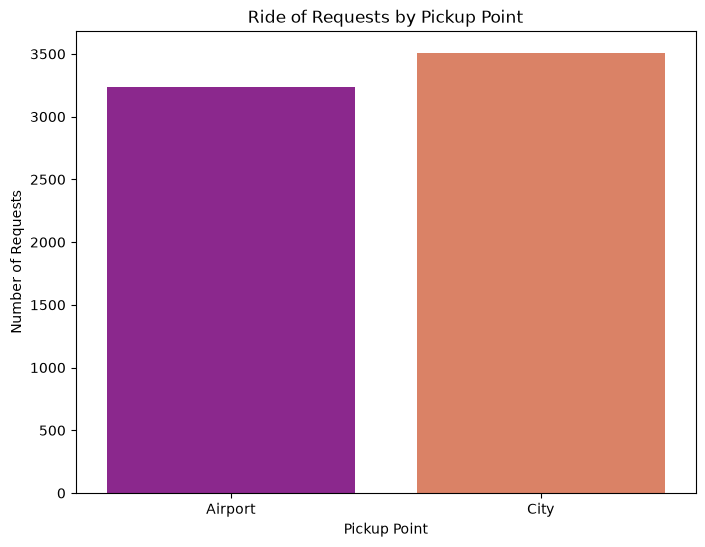

In [67]:
# Chart - 2 visualization code
plt.figure(figsize=(8,6))
sns.countplot(x='Pickup point', data=df, palette='plasma')
plt.title('Ride of Requests by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.show()

##### 1. Why did you pick the specific chart?

I selected a count plot because Pickup point is a categorical variable. It helps compare the number of ride requests from Airport and City in simple and clear.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride requests from the City are slightly higher than those from the Airport. This indicates that the City generates more ride demand than the Airport.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights help Uber understand where ride demand is higher so that more drivers can be allocated to high-demand locations, reducing waiting time and improving customer satisfaction. If there are not enough drivers available in the City, it may lead to cancelled rides or "No Cars Available" requests, resulting in lost customers and reduced revenue.

#### Chart - 3

In [68]:
df["Hour"] = df['Request timestamp'].dt.hour
df[['Request timestamp', 'Hour']].head()

,Request timestamp,Hour
0,2016-11-07 11:51:00,11
1,2016-11-07 17:57:00,17
2,2016-12-07 09:17:00,9
3,2016-12-07 21:08:00,21
4,2016-07-13 08:33:16,8


C:\Users\Manas Kadu\AppData\Local\Temp\ipykernel_24228\1019134795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='plasma')


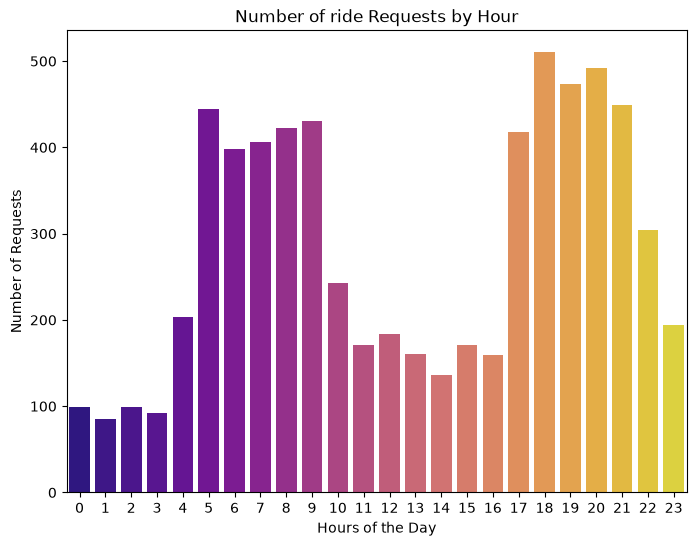

In [69]:
# Chart - 3 visualization code
plt.figure(figsize=(8,6))
sns.countplot(x='Hour', data=df, palette='plasma')
plt.title('Number of ride Requests by Hour')
plt.xlabel('Hours of the Day')
plt.ylabel('Number of Requests')
plt.show()

##### 1. Why did you pick the specific chart?

I selected a count plot because the Hour column contains discrete values (0–23). The chart clearly shows the number of ride requests in each hour of the day and helps identify peak demand hours.

##### 2. What is/are the insight(s) found from the chart?

The chart shows two peak demand periods: morning (5 AM–9 AM) and evening (5 PM–9 PM). The highest number of ride requests is around 6 PM, while the lowest demand occurs between 12 AM and 4 AM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Uber can increase the number of drivers during peak hours to reduce customer waiting time, ride cancellations, and "No Cars Available" requests. If enough drivers are not available during these busy hours, it can lead to lost customers, lower revenue, and reduced customer satisfaction.

#### Chart - 4

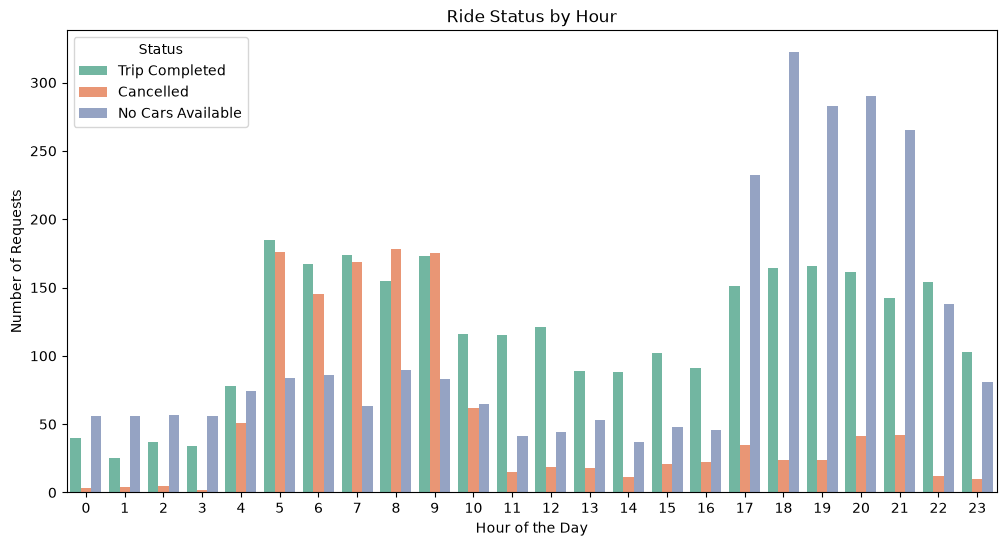

In [70]:
# Chart - 4 visualization code
plt.figure(figsize=(12,6))

sns.countplot(data=df, x= "Hour", hue="Status", palette="Set2")

plt.title("Ride Status by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Requests")

plt.legend(title="Status")

plt.show()

##### 1. Why did you pick the specific chart?

I selected a count plot with the hue parameter because it compares two categorical variables (Hour and Status). It helps identify how ride statuses change throughout different hours of the day.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride requests are highest during the morning (5 AM–9 AM) and evening (5 PM–9 PM). During these peak hours, the number of cancelled rides and "No Cars Available" requests also increases, indicating a supply-demand gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights show that ride cancellations and "No Cars Available" requests increase during peak hours (5 AM–9 AM and 5 PM–9 PM), indicating a supply-demand gap. Uber can improve its service by increasing the number of drivers during these hours. If this issue is not addressed, it may lead to longer waiting times, higher cancellation rates, poor customer satisfaction, and loss of revenue.

#### Chart - 5

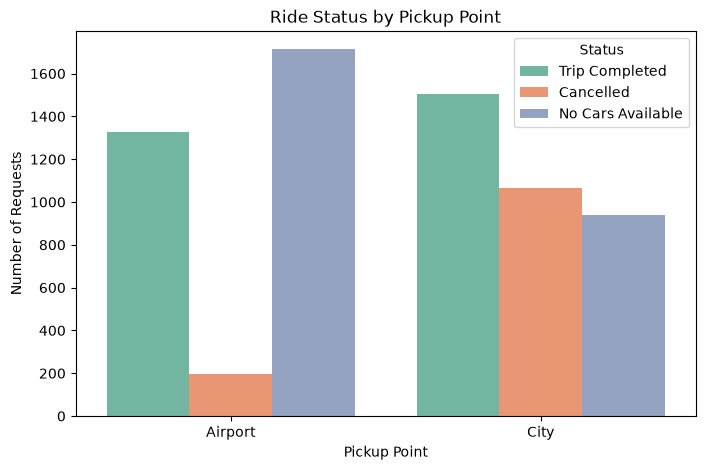

In [71]:
# Chart - 5 visualization code
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Pickup point", hue="Status", palette="Set2")

plt.title("Ride Status by Pickup Point")
plt.xlabel("Pickup Point")
plt.ylabel("Number of Requests")

plt.legend(title="Status")

plt.show()

##### 1. Why did you pick the specific chart?

I selected a count plot with the hue parameter because it compares two categorical variables (Pickup Point and Status). It helps visualize the distribution of ride statuses at each pickup location

##### 2. What is/are the insight(s) found from the chart?

The Airport has more "No Cars Available" requests, while the City has more cancelled and completed trips. This indicates that driver availability is lower at the Airport, whereas the City experiences more ride activity overall.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Uber can improve driver allocation at the Airport to reduce "No Cars Available" requests. In the City, Uber can analyze the reasons for ride cancellations and take steps to reduce them. These improvements can increase customer satisfaction and revenue.

#### Chart - 6

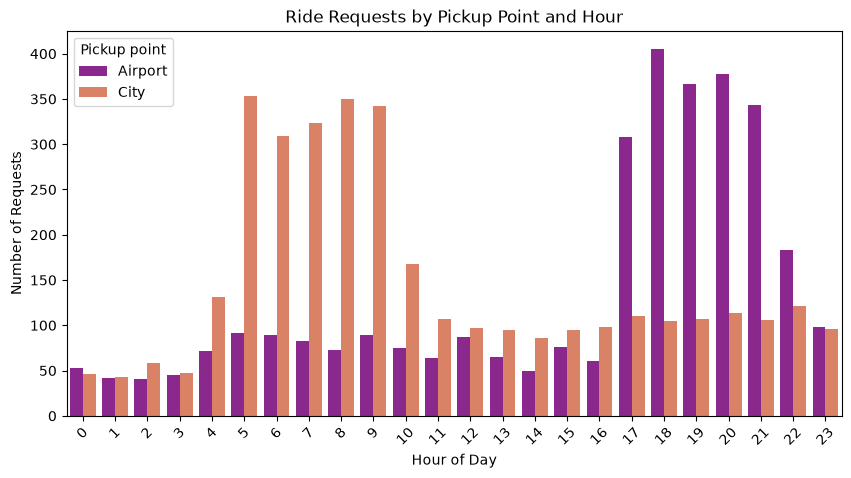

In [72]:
# Chart - 6 visualization code
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Hour',
    hue='Pickup point',
    palette='plasma'
)

plt.title("Ride Requests by Pickup Point and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

I selected this chart to compare ride requests at different pickup points (Airport and City) during different hours of the day. It helps identify demand patterns at each location.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride demand varies by hour for both pickup points. The City receives more ride requests during most hours, while the Airport experiences higher demand during certain peak hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights help Uber allocate more drivers according to demand at each pickup point and during peak hours. If driver allocation is not optimized, customers may face longer waiting times, ride cancellations, and "No Cars Available" requests, resulting in reduced customer satisfaction and revenue

#### Chart - 7

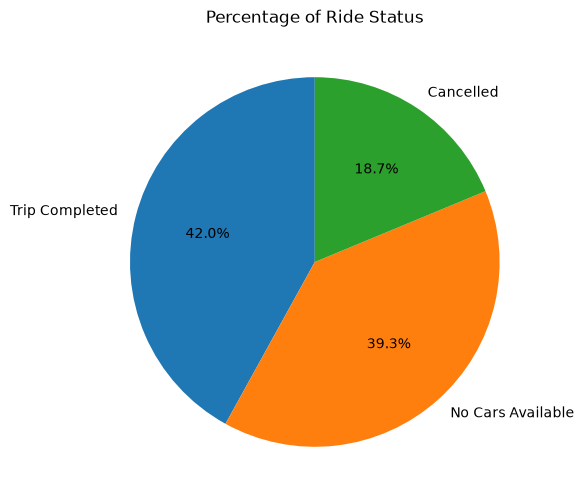

In [73]:
# Chart - 7 visualization code
status_counts = df['Status'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage of Ride Status")
plt.show()

##### 1. Why did you pick the specific chart?

I selected a pie chart to show the percentage distribution of different ride statuses. It provides a quick understanding of the proportion of completed, cancelled, and unavailable rides.

##### 2. What is/are the insight(s) found from the chart?

The pie chart shows that most ride requests are completed, while a smaller percentage are cancelled or marked as "No Cars Available". This gives an overall view of Uber's ride outcomes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart helps evaluate Uber's overall service performance. Increasing the percentage of completed rides while reducing cancellations and unavailable rides can improve customer satisfaction, operational efficiency, and revenue.

#### Chart - 8

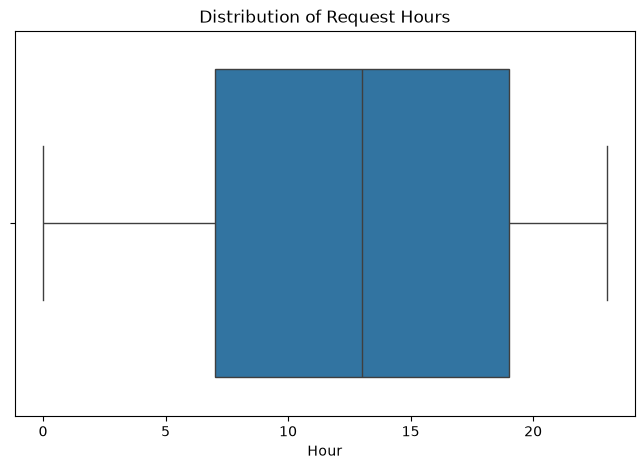

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Hour'])

plt.title("Distribution of Request Hours")
plt.xlabel("Hour")

plt.show()

##### 1. Why did you pick the specific chart?

I selected a box plot to understand the distribution of ride request hours and identify the spread of requests across the day. It also helps detect any unusual values or outliers.

##### 2. What is/are the insight(s) found from the chart?

The box plot shows how ride requests are distributed throughout the day. It highlights the concentration of requests within certain time ranges and indicates whether there are any extreme request hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the distribution of ride requests helps Uber plan driver shifts more effectively. Better scheduling can reduce waiting time, improve ride availability, and enhance customer experience.

####  Chart - 9 - Correlation Heatmap

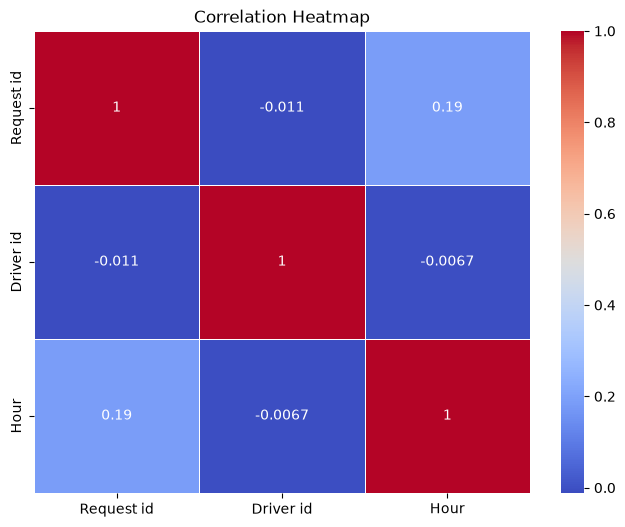

In [75]:
# Chart - 9 visualization code
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

I selected a heatmap to visualize the correlation between numerical variables. It helps identify whether any numerical features are positively or negatively related.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that there is no strong correlation among the numerical variables in the dataset. This indicates that the main business insights come from categorical variables such as Status, Pickup Point, and Hour.

#### Chart - 10- Pair Plot

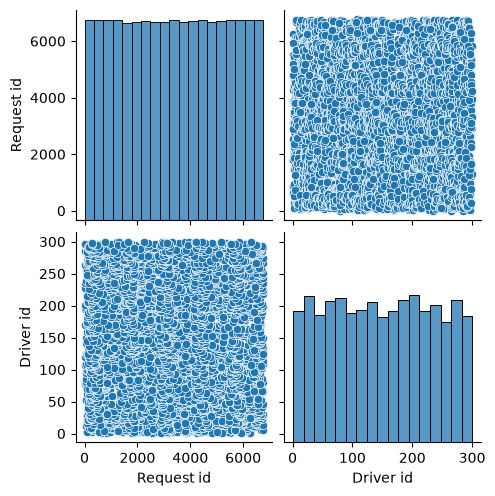

In [76]:
# Chart - 10 visualization code
sns.pairplot(
    df.select_dtypes(include=['int64','float64'])
)

plt.show()

##### 1. Why did you pick the specific chart?

I selected a pair plot to visualize the relationships and distributions of all numerical variables in a single figure.  

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows the distribution of numerical variables and confirms that there are no strong linear relationships or unusual patterns among them.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Uber should increase driver availability during peak demand hours, especially at the Airport where many requests fail due to "No Cars Available". The company should also reduce ride cancellations through better driver management and demand forecasting. Proper driver allocation based on location and time can help balance the supply-demand gap, improve customer satisfaction, and increase completed rides and revenue.

# **Conclusion**

The EDA of the Uber Supply Demand Gap dataset identified the major reasons behind unsuccessful rides. The analysis showed that ride demand is highest during peak hours, while the Airport experiences a large number of "No Cars Available" requests and the City has more ride cancellations. By increasing driver availability during high-demand periods and reducing cancellations, Uber can improve ride completion rates, enhance customer satisfaction, and increase overall business performance.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***